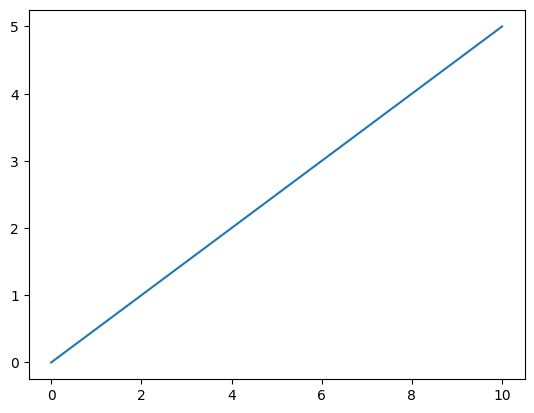

In [2]:
# simulating binary stars in python
import numpy as np 
import matplotlib.pyplot as plt
x= [0]
y= [0]
for i in range(10):
    x.append(x[-1] + 1) #move right
    y.append(y[-1] + 0.5) #move up

plt.plot(x, y)
plt.show()

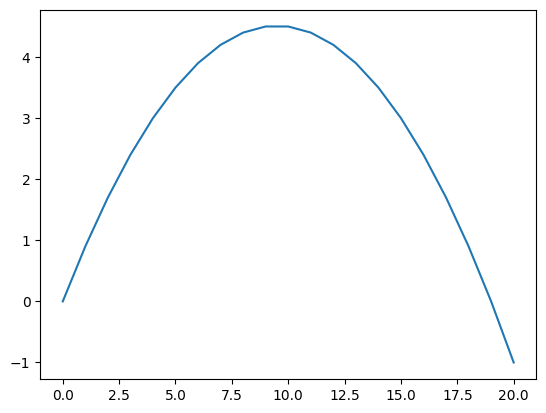

In [3]:
vx=1
vy=1
x=[0]
y=[0]
for i in range(20):
    ax=0
    ay=-0.1
    vx += ax
    vy += ay
    x.append(x[-1] + vx)
    y.append(y[-1] + vy)
plt.plot(x, y)
plt.show()

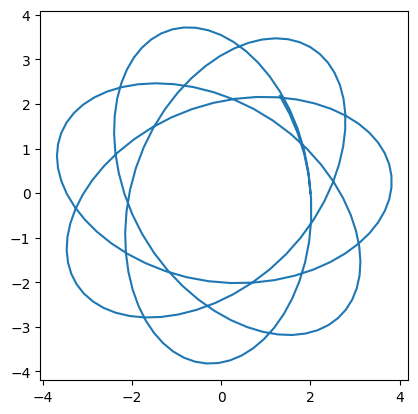

In [5]:
x= [2.0]
y= [0.0]
vx=0
vy=0.5
for i in range(200):
    dx = -x[-1]
    dy = -y[-1]
    dist = (dx**2 + dy**2)**0.5
    ax = dx / dist*0.05
    ay = dy / dist*0.05
    vx += ax
    vy += ay
    x.append(x[-1] + vx)
    y.append(y[-1] + vy)
plt.plot(x, y)
plt.gca().set_aspect('equal')
plt.show()

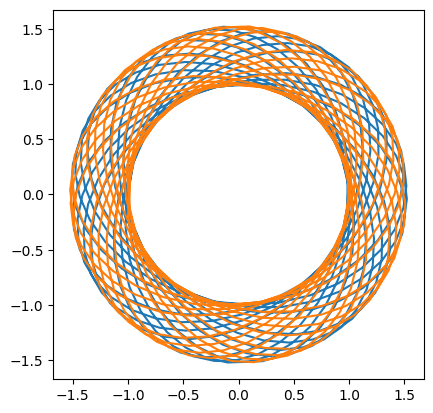

In [2]:
import matplotlib.pyplot as plt

#star 1
x1, y1 = -1.0, 0.0
vx1, vy1= 0, -0.3
#star 2
x2, y2 = 1.0, 0.0
vx2, vy2 = 0, 0.3

path1_x, path1_y = [], []
path2_x, path2_y = [], []

for i in range(500):
    dx = x2 - x1
    dy = y2 - y1
    dist = (dx**2 + dy**2)**0.5

    ux = dx / dist
    uy = dy / dist

    strength=0.05 #like gravity strength

    ax1 = ux * strength
    ay1 = uy * strength
    ax2 = -ux * strength
    ay2 = -uy * strength

    vx1 += ax1
    vy1 += ay1
    vx2 += ax2
    vy2 += ay2

    x1 += vx1
    y1 += vy1
    x2 += vx2
    y2 += vy2

    path1_x.append(x1)
    path1_y.append(y1)
    
    path2_x.append(x2)
    path2_y.append(y2)

plt.plot(path1_x, path1_y)
plt.plot(path2_x, path2_y)
plt.gca().set_aspect('equal')
plt.show()




In [38]:
#imma animate ts
import matplotlib
matplotlib.use('TkAgg') #stable backend that actually shows animations
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np

m1=10
m2=5

x1, y1 = -1.0, 0.0
x2, y2 = 1.0, 0.0

vx1, vy1 = 0.0, -0.15
vx2, vy2 = 0.0, 0.30

dt=0.01

path1_x, path1_y = [], []
path2_x, path2_y = [], []

#explosion flag
exploded = False

fig, ax = plt.subplots() #figure
line1, = ax.plot([], [], color='orange', alpha=0.6) #trails (glowy)
line2, = ax.plot([], [], color='blue', alpha=0.6)

point1, = ax.plot([], [], 'o', color='gold', markersize=8)
point2, = ax.plot([], [], 'o', color='cyan', markersize=6)

stars_x = np.random.uniform(-3, 3, 100) # background stars 
stars_y = np.random.uniform(-3, 3, 100)
ax.scatter(stars_x, stars_y, color='white', s=1)

ax.set_xlim(-3,3)
ax.set_ylim(-3,3)
ax.set_aspect('equal')
ax.set_facecolor('black')
fig.patch.set_facecolor('black')

def init():
    line1.set_data([], [])
    line2.set_data([], [])
    point1.set_data([], [])
    point2.set_data([], [])
    return line1, line2, point1, point2

def update(frame):
    global x1, y1, vx1, vy1, x2, y2, vx2, vy2, exploded
    
    dx = x2 - x1
    dy = y2 - y1
    dist = (dx**2 + dy**2)**0.5
    
    if dist == 0:   # VERY IMPORTANT SAFETY DONT MISS IT RAHHH
        return line1, line2, point1, point2
    
    ux = dx / dist
    uy = dy / dist
        
    if dist<0.2 and not exploded: #collision check lol
        print("💥 BOOM SUPERNOVA 💥")
        exploded = True
        vx1 = vy1 = vx2 = vy2 = 0

        # give instant explosion kick
        vx1 = -ux * 2
        vy1 = -uy * 2
        vx2 = ux * 2
        vy2 = uy * 2


# ⭐ NORMAL GRAVITY (ONLY BEFORE EXPLOSION)
    if not exploded:
        G = 1
        force = G * m1 * m2 / (dist**2)

        ax1 = force * ux / m1
        ay1 = force * uy / m1

        ax2 = -force * ux / m2
        ay2 = -force * uy / m2

        vx1 += ax1 * dt
        vy1 += ay1 * dt
        vx2 += ax2 * dt
        vy2 += ay2 * dt

    # update positions (ALWAYS)
    x1 += vx1 * dt
    y1 += vy1 * dt
    x2 += vx2 * dt
    y2 += vy2 * dt

    path1_x.append(x1)
    path1_y.append(y1)
    
    path2_x.append(x2)
    path2_y.append(y2)

    line1.set_data(path1_x, path1_y)
    line2.set_data(path2_x, path2_y)

    point1.set_data([x1], [y1])
    point2.set_data([x2], [y2])

    return line1, line2, point1, point2

anim = FuncAnimation(fig, update, frames=800, interval=30, init_func=init)
plt.show()

💥 BOOM SUPERNOVA 💥
